### Day 8
#### In this notebook we will be building A langgraph Graph without coding all the logic behind it
#### for that we need :
- some dummy functions to call as nodes, for now. we will add logic in next the notebook
- a TypedDict class state : to pass it through the nodes for I/O

---
## 1. Imports

In [ ]:
from typing import TypedDict, Annotated, Optional
import operator
from langgraph.graph import StateGraph, START, END

c:\Users\Amit\anaconda3\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


---
## 2. State

### State Definition
- Defines the shared state TypedDict that flows through every node.
- Every node reads from and writes to this single state object.

In [84]:
class State(TypedDict):
  topic:str                       # user input
  subtopic:str                    # for researcher agent
  level: str                      # beginner/medium/advanced
  study_plan : Optional[dict]     # planner output 
  notes: Optional[dict]           # researcher output / ChromaDB retrieval
  sources : Optional[list]        # URLs from Tavily
  memory_saved : Optional[bool]   # bool confirming ChromaDB write
  quiz_questions: Optional[list]  # list of questions from quiz node
  user_answers: Optional[list]    # list of answers from user
  feedback : Optional[str]        # per-question feedback from evaluator
  scores : list[int]                    # int 0-100 from evaluator
  retries: int                    # int, starts at 0, max 2
  errors: Annotated[list[str],operator.add] # any node's error message

---
## 3. Nodes

### Planner NODE 
- Creates a detailed study plan

In [97]:
# planner_node: entry point — generates 5-day study plan from topic + level
def planner_node(state:State):
  topic = state['topic']
  level = state['level']
  return {"study_plan":{"placeholder":"plans maded by planner agent"}}

### Memory-reader NODE:
- checks for existing notes

In [82]:
# checks chroma db for existing notes
def memory_reader_node(state:State):
  subtopic = state['subtopic']
  return None

#### Researcher NODE:
- Creates notes on subtopics

In [103]:
def researcher_node(state:State):
  subtopic = state['subtopic']
  level = state['level']

  return {"notes":{"placeholder":"notes made by researcher"},"sources":["source_link_1","source_link_2"]}

### Memory Writer NODE:
- Writes generated notes to memory for furthur quizes

In [24]:
def memory_writer_node(state:State):
  notes = state['notes']
  subtopic = state['subtopic']
  return {"memory_saved":True}

### Quiz NODE :
- Generates quiz from the notes

In [ ]:
def quiz_node(state:State):
  notes = state['notes']
  return {"quiz_questions":{"placeholder":"some quiz"}}

### Evaluator NODE:
- Evaluates user's answer with quiz questions

In [88]:
def evaluation_node(state:State):
  quiz_questions = state['quiz_questions']
  user_answers = state['user_answers']
  return {"scores":[2,2,3],"feedback":"feedback"}

### Retry tracker node :
- tracks retries 

In [89]:
def retry_tracker_node(state:State):
  retries = state['retries']
  return {"retries":retries+1,"error": f"Retry {retries + 1} triggered due to low score"}

---
## 4. Routers : 
- Reads from state but never writes back.

### Route after memory function :
- for routing in between quiz NODE & researcher NODE

In [90]:
def route_after_memory(state:State):
  notes = state['notes']
  if notes is None:
    return "researcher_node"
  else:
    return "quiz_node"

### Route after evaluation function:
- for routing inn between retry_tracker_node and END

In [91]:
def route_after_evaluation(state:State):
  score = state['scores']
  retries = state['retries']

  average = sum(state['scores']) / len(state['scores'])

  if  retries < 2 and average < 0.6:
    return "retry_tracker_node"
  else:
    return END


---
## 5. Graph
## ⬇️ Graph Assembly
---
- Add functions as NODE first

In [94]:
graph_builder = StateGraph(State)

graph_builder.add_node("planner_node",planner_node)
graph_builder.add_node("memory_reader_node",memory_reader_node)
graph_builder.add_node("researcher_node",researcher_node)
graph_builder.add_node("memory_writer_node",memory_writer_node)
graph_builder.add_node("quiz_node",quiz_node)
graph_builder.add_node("evaluation_node",evaluation_node)
graph_builder.add_node("retry_tracker_node",retry_tracker_node)

- Add edges :Connection between above defined nodes
- Direct Edges & Conditional Edges

In [95]:
graph_builder.add_edge(START, "planner_node")
graph_builder.add_edge("planner_node", "memory_reader_node")

graph_builder.add_conditional_edges(
    "memory_reader_node",
    route_after_memory,
    {
        "researcher_node": "researcher_node",
        "quiz_node": "quiz_node"
    }
)

graph_builder.add_edge("researcher_node", "memory_writer_node")
graph_builder.add_edge("memory_writer_node", "quiz_node")
graph_builder.add_edge("quiz_node", "evaluation_node")

graph_builder.add_conditional_edges(
    "evaluation_node",
    route_after_evaluation,
    {
        "retry_tracker_node": "retry_tracker_node",
        END:END
    }
)

graph_builder.add_edge("retry_tracker_node", "researcher_node")


### Compile the graph

In [96]:
graph = graph_builder.compile()

### Graph Diagram 🥁 

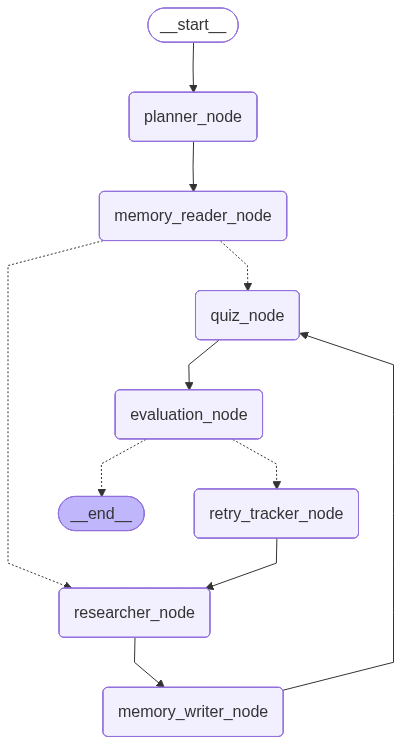

In [79]:
from IPython.display import Image, display

def display_graph(graph):
  return display(Image(graph.get_graph().draw_mermaid_png()))

display_graph(graph)

#### Observations
- Solid lines → regular edges
- Dotted lines → conditional edges

---
## 6.Test

In [102]:
initial_state = {
    "topic": "Python OOP",
    "level": "medium",
    "subtopic": "Inheritance",
    "notes": None,         
    "study_plan": None,
    "sources": [],
    "memory_saved": False,
    "quiz_questions": [],
    "user_answers": ["answer1", "answer2"],
    "scores": [],
    "feedback": None,
    "retries": 0,
    "error": None
}

result = graph.invoke(initial_state)
print(len(initial_state))
for k,v in result.items():
  print(f"{k} : {v}")
print(len(result))

13
topic : Python OOP
subtopic : Inheritance
level : medium
study_plan : {'placeholder': 'plans maded by planner agent'}
notes : {'placeholder': 'notes made by researcher'}
sources : ['surce_link_1', 'surce_link_2']
memory_saved : True
quiz_questions : {'placeholder', 'some quiz'}
user_answers : ['answer1', 'answer2']
feedback : feedback
scores : [2, 2, 3]
retries : 0
errors : []
13


## ✅ Summary
| Component | Status |
|---|---|
| Planner Node | ✅ Working |
| Memory Reader | ✅ Working |
| Researcher Node | ✅ Working |
| Memory Writer | ✅ Working |
| Quiz Node | ✅ Working |
| Evaluator Node | ✅ Working |
| Retry Tracker | ✅ Working |
| Conditional Edges | ✅ Working |
| Graph Compiled | ✅ Working |

## What's Next
- Replace dummy functions with real agents
- Connect real ChromaDB
- Add Streamlit UI